# Trabajo Práctico 2 — Clasificación de Géneros Musicales
**Tecnología Digital VI - Inteligencia Artificial**  
Universidad Torcuato Di Tella — 1er Semestre 2026

---

## Objetivo

Predecir el género musical de una canción (```jazz```, ```electronic```, ```hip-hop```, ```acoustic```, ```rock```, ```classical```) a partir de sus métricas acústicas de Spotify. Se evalúa con **F1-Score Macro** en la competencia de Kaggle, y complementariamente con **MAP@3** para simular el contexto real de un sistema de recomendación.

## 1. Imports y configuración

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import lightgbm as lgb

from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

## 2. Carga y primera inspección de los datos

In [16]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print()
train.describe()

Train shape: (4200, 17)
Test  shape: (1800, 16)



,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Id
count,4200.000000,4.200000e+03,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.00000
mean,28.379524,2.166272e+05,0.560357,0.505509,5.233571,-10.190675,0.667143,0.068335,0.462576,0.170266,0.175381,0.459639,117.591598,3.874286,2991.09119
std,27.610356,1.090433e+05,0.173039,0.271108,3.589029,6.446329,0.471292,0.071875,0.375937,0.326240,0.136275,0.248920,30.394517,0.481529,1729.94323
min,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.531000,0.000000,0.000000,0.000006,0.000000,0.017900,0.000000,0.000000,0.000000,2.00000
25%,0.000000,1.659868e+05,0.443000,0.278000,2.000000,-12.472000,0.000000,0.034100,0.075400,0.000000,0.097500,0.250000,93.931000,4.000000,1490.75000
50%,28.000000,2.038800e+05,0.571000,0.529000,5.000000,-8.187000,1.000000,0.043200,0.417000,0.000052,0.121000,0.445500,116.098000,4.000000,2999.00000
75%,55.000000,2.470400e+05,0.689000,0.737000,8.000000,-5.773250,1.000000,0.065100,0.853000,0.075275,0.209000,0.650000,136.470000,4.000000,4481.25000
max,92.000000,2.646866e+06,0.959000,0.997000,11.000000,-0.927000,1.000000,0.905000,0.996000,0.978000,0.962000,0.980000,214.016000,5.000000,5999.00000


In [17]:
print('Nulls en train:', train.isnull().sum().sum())
print('Nulls en test: ', test.isnull().sum().sum())
print()
print('Tipos de datos:')
print(train.dtypes)
print()
print('Distribución de clases:')
print(train['Expected'].value_counts())

Nulls en train: 0
Nulls en test:  0

Tipos de datos:
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected             object
Id                    int64
dtype: object

Distribución de clases:
Expected
jazz          700
electronic    700
hip-hop       700
acoustic      700
rock          700
classical     700
Name: count, dtype: int64


## 3. Análisis Exploratorio de Datos (EDA)

El dataset tiene **6 géneros perfectamente balanceados** (700 canciones cada uno) y **14 features acústicas** de Spotify. No hay valores nulos.

### Visualización 1: Distribución de features clave por género

Buscamos qué _features_ discriminan mejor entre géneros.

KeyboardInterrupt: 

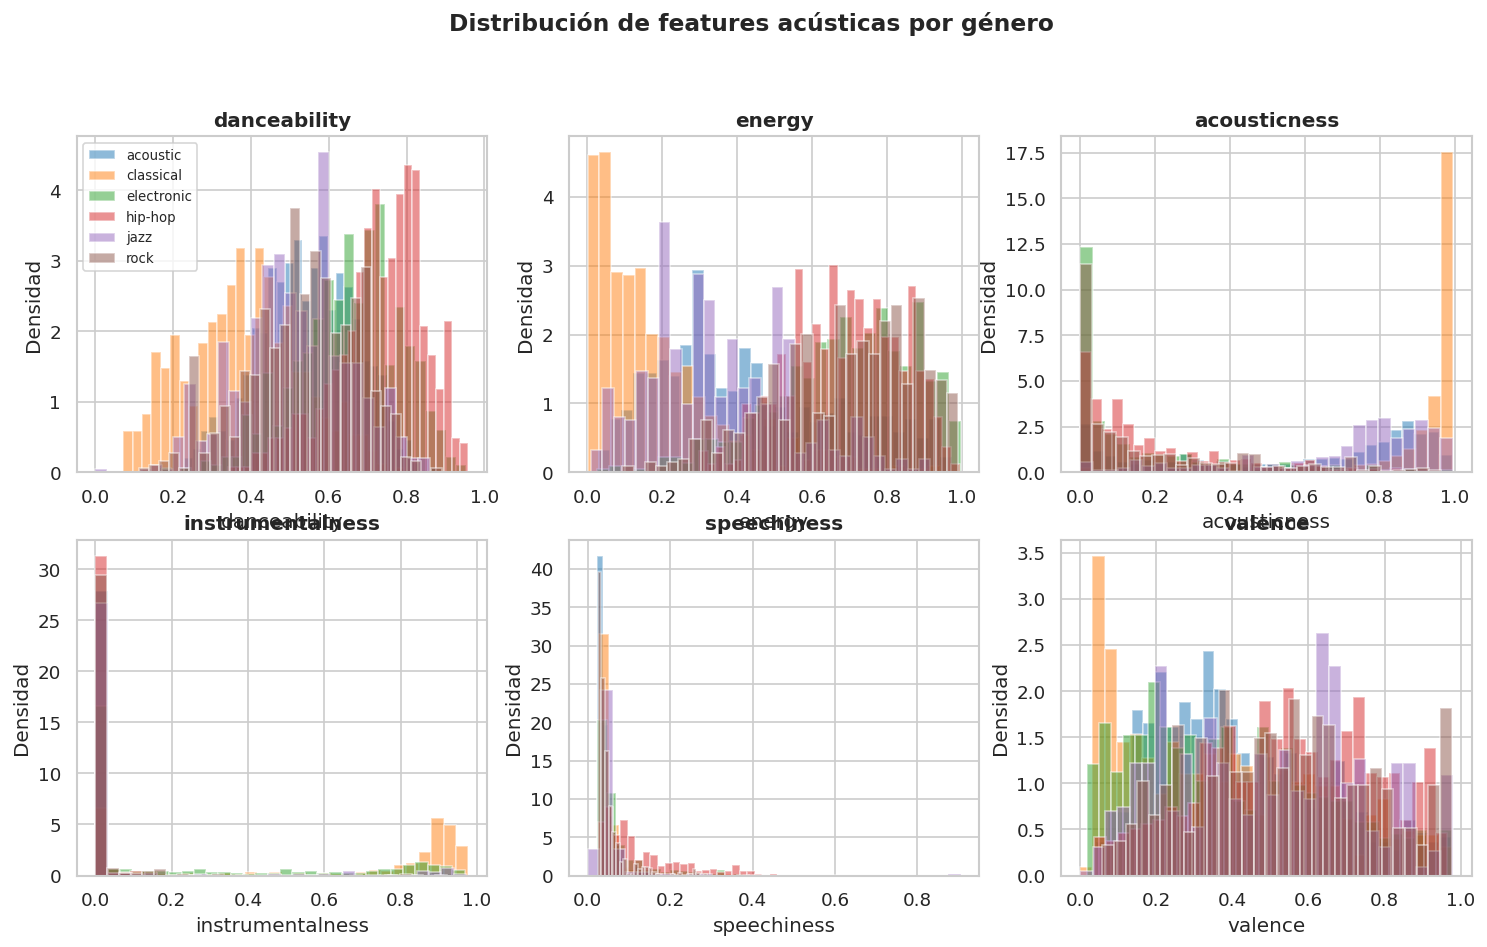

In [18]:
key_features = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'speechiness', 'valence']
genres = train['Expected'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for genre in sorted(genres):
        data = train[train['Expected'] == genre][feat]
        ax.hist(data, bins=30, alpha=0.5, label=genre, density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Densidad')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Distribución de features acústicas por género', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_distributions.png', bbox_inches='tight')
plt.show()

Observaciones:
- ```acousticness```: acoustic y classical concentradas en valores altos (>0.6);
  electronic y hip-hop en valores bajos (<0.2).
- ```speechiness```: hip-hop claramente separado con valores altos (rap/spoken word).
- ```instrumentalness```: classical y electronic tienen picos cerca de 1.0 (sin voz);
  hip-hop y rock cerca de 0 (con voz).
- ```danceability```: hip-hop y electronic tienen los valores más altos; classical los más bajos.

### Visualización 2: Boxplots comparativos de features más discriminantes

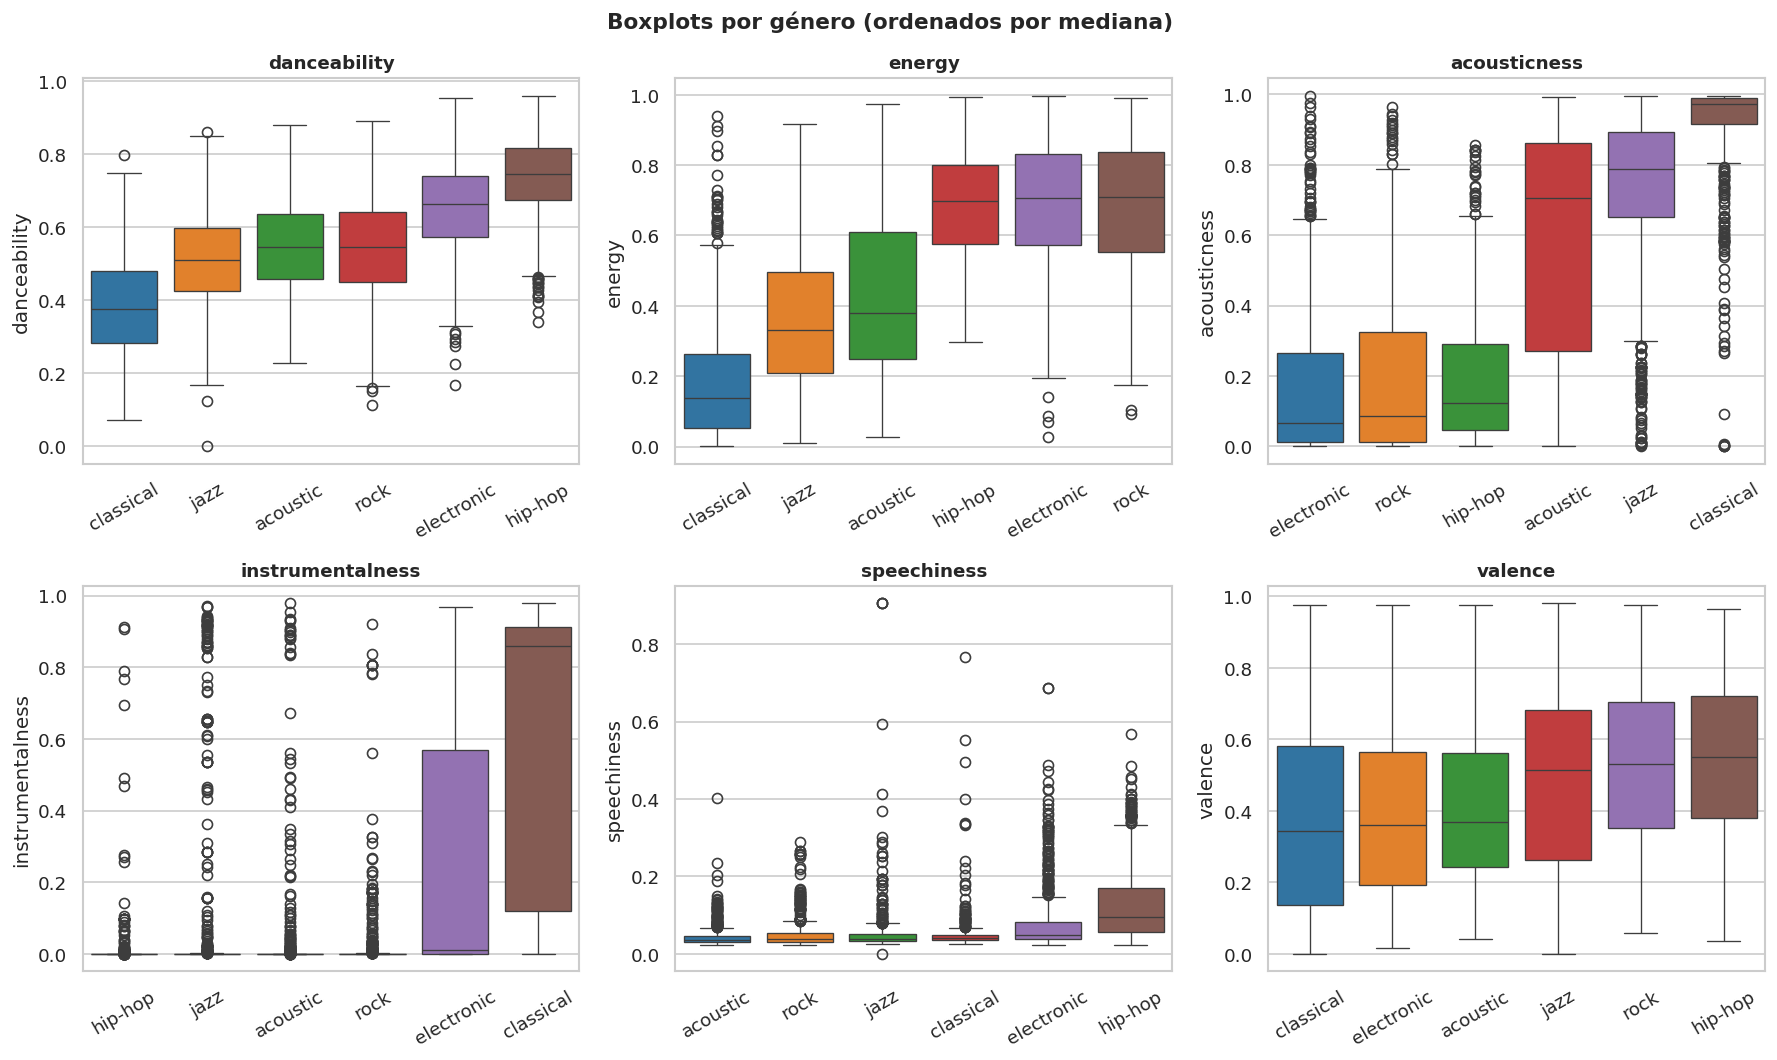

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    order = train.groupby('Expected')[feat].median().sort_values().index.tolist()
    sns.boxplot(data=train, x='Expected', y=feat, order=order, ax=ax,
                palette='tab10', linewidth=0.8)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Boxplots por género (ordenados por mediana)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_boxplots.png', bbox_inches='tight')
plt.show()

Observaciones:
- jazz y acoustic son los géneros más difíciles de separar en _features_ individuales.
- rock tiene ```energy``` alta y ```acousticness``` baja.
- classical tiene ```instrumentalness``` muy alta y ```danceability``` baja.
- la combinación de múltiples _features_ es necesaria para una buena clasificación.

### Visualización 3: Correlación entre features y mapa de medias por género

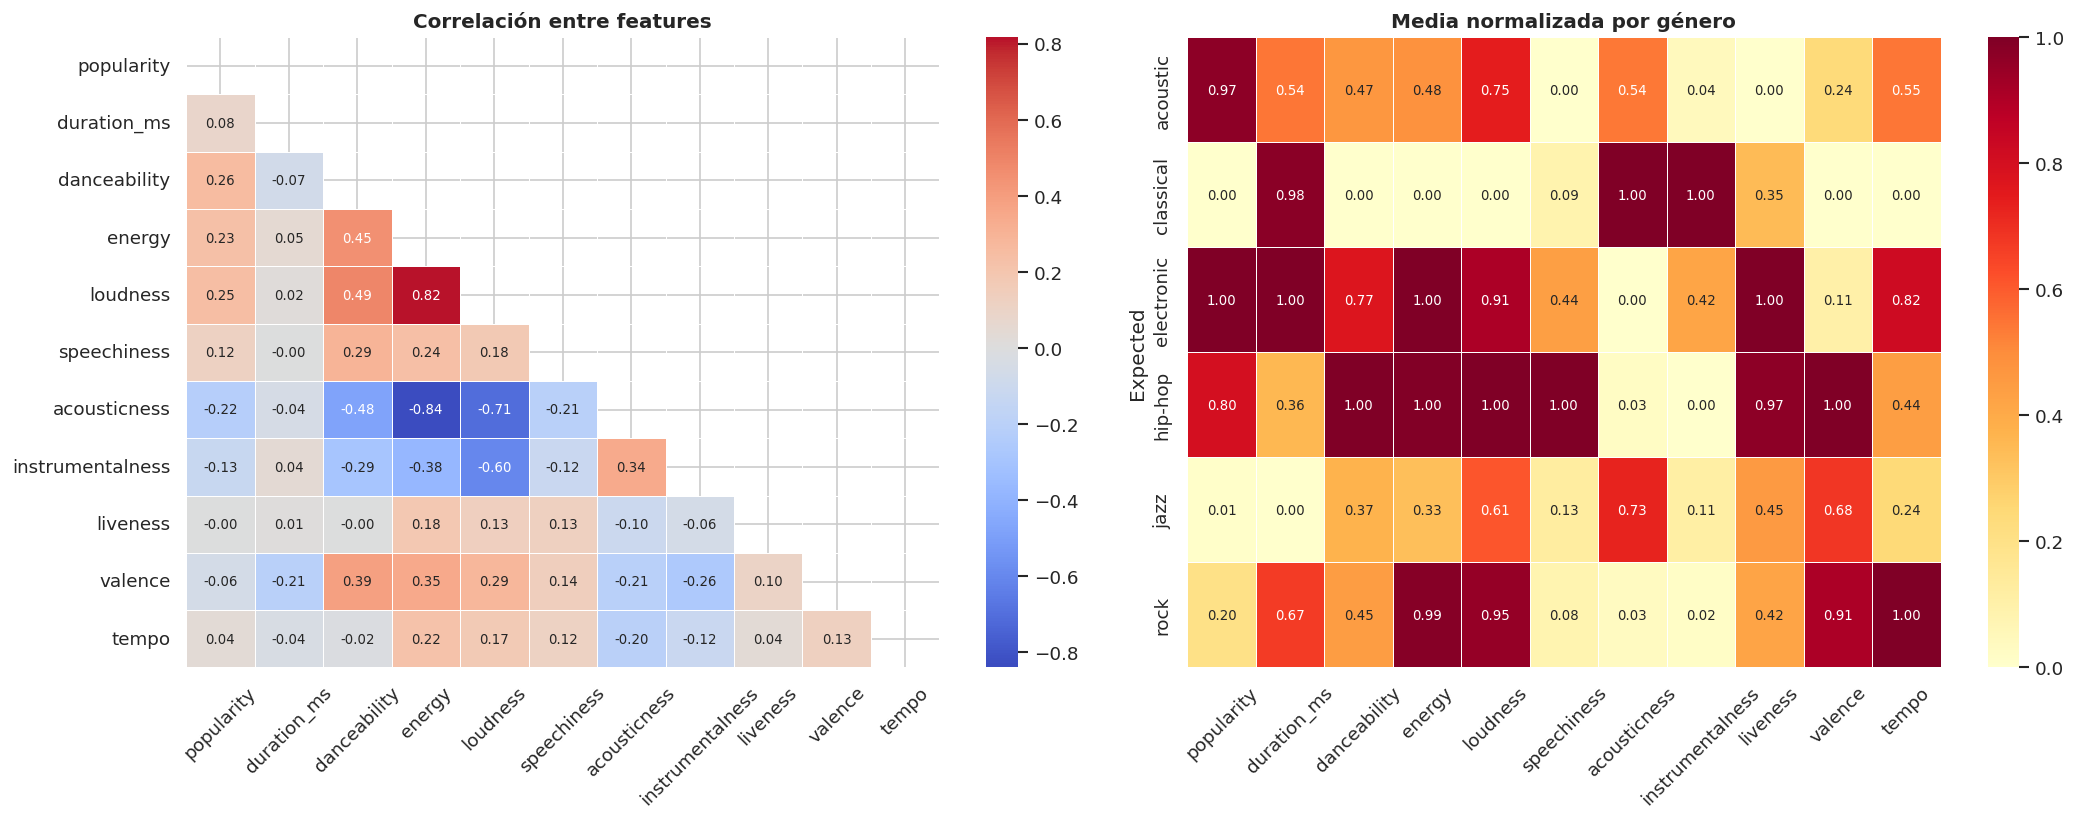

In [ ]:
numeric_features = ['popularity', 'duration_ms', 'danceability', 'energy',
                    'loudness', 'speechiness', 'acousticness',
                    'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de correlación
corr = train[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Correlación entre features', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap de medias por género (normalizado)
genre_means = train.groupby('Expected')[numeric_features].mean()
genre_means_norm = (genre_means - genre_means.min()) / (genre_means.max() - genre_means.min())
sns.heatmap(genre_means_norm, ax=axes[1], annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Media normalizada por género', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz3_heatmaps.png', bbox_inches='tight')
plt.show()

Observaciones:
- ```energy``` y ```loudness``` tienen correlación alta (0.73): ambas capturan 'intensidad'.
- ```acousticness``` y ```energy``` correlacionan negativamente (-0.65): tiene sentido físico.
- classical: alta ```instrumentalness```, baja ```speechiness```, baja ```danceability```.
- hip-hop: alta ```speechiness```, alta ```danceability```, baja ```acousticness```.
- electronic: alta ```energy```, alta ```danceability```, baja ```acousticness```.

## 4. Preprocesamiento

### Decisiones tomadas:

1. **`explicit` (bool → int)**: Convertimos a 0/1. Es una feature categórica binaria con información potencialmente útil (el hip-hop suele tener más contenido explícito).

2. **`duration_ms` → `duration_min`**: Escala más interpretable. No cambia la información, sólo la unidad.

3. **Features descartadas**: `Id` es un identificador sin información. `key` y `mode` son categorías musicales (tonalidad) que codificamos como están, ya que los árboles pueden manejarlas directamente.

4. **Escalado**: Aplicamos `RobustScaler` para modelos que lo requieren (LR, SVM, KNN). Es más robusto ante outliers que `StandardScaler`. Los modelos basados en árboles no necesitan escalado.

5. **Feature engineering**: Creamos `energy_acousticness_ratio` y `dance_energy` como features derivadas que capturan interacciones relevantes.

In [ ]:
def preprocess(df, is_train=True):
    df = df.copy()
    
    # explicit bool → int
    df['explicit'] = df['explicit'].astype(int)
    
    # duración en minutos (más interpretable)
    df['duration_min'] = df['duration_ms'] / 60000
    df = df.drop(columns=['duration_ms'])
    
    # Feature engineering: interacciones relevantes
    df['energy_acousticness_ratio'] = df['energy'] / (df['acousticness'] + 1e-6)
    df['dance_energy'] = df['danceability'] * df['energy']
    df['instrumental_acoustic'] = df['instrumentalness'] * df['acousticness']
    
    # Separar features del target
    drop_cols = ['Id']
    if is_train:
        drop_cols.append('Expected')
    
    X = df.drop(columns=drop_cols)
    return X

X_train = preprocess(train, is_train=True)
y_train = train['Expected']
X_test  = preprocess(test,  is_train=False)

print('Features finales:', X_train.columns.tolist())
print('Shape X_train:', X_train.shape)
print('Shape X_test: ', X_test.shape)

Features finales: ['popularity', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min', 'energy_acousticness_ratio', 'dance_energy', 'instrumental_acoustic']
Shape X_train: (4200, 18)
Shape X_test:  (1800, 18)


In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y_train)
classes = le.classes_
print('Clases:', classes)

Clases: ['acoustic' 'classical' 'electronic' 'hip-hop' 'jazz' 'rock']


## 5. Métricas

### 5.1 F1-Score Macro (métrica de Kaggle)

Promedio no ponderado del F1 de cada clase. Como las clases están balanceadas, es equivalente al F1 micro en este caso. Castiga por igual todos los errores.

### 5.2 MAP@3 — Mean Average Precision at K=3

En un sistema de recomendación, el modelo no devuelve una única predicción sino un ranking de las 3 más probables. MAP@3 mide si la respuesta correcta aparece en ese top-3 y en qué posición.

$$\text{MAP@3} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\min(m_i, 3)} \sum_{k=1}^{3} P(k) \cdot \text{rel}(k)$$

donde $P(k)$ es la precisión en el corte $k$ y $\text{rel}(k)=1$ si la predicción en posición $k$ es correcta.

In [ ]:
def average_precision_at_k(y_true_single, y_pred_top3):
    """Average precision para una sola muestra con top-3 predicciones."""
    hits = 0
    score = 0.0
    for k, pred in enumerate(y_pred_top3, start=1):
        if pred == y_true_single:
            hits += 1
            score += hits / k
    return score  # máx 1.0 si acierta en posición 1

def map_at_3(y_true, y_pred_proba, classes):
    """
    MAP@3: Mean Average Precision at K=3.
    
    Args:
        y_true: array de etiquetas verdaderas (strings)
        y_pred_proba: matriz (n_samples, n_classes) de probabilidades
        classes: orden de las clases en y_pred_proba
    """
    y_true = np.array(y_true)
    scores = []
    for i in range(len(y_true)):
        top3_idx = np.argsort(y_pred_proba[i])[::-1][:3]
        top3_classes = [classes[j] for j in top3_idx]
        ap = average_precision_at_k(y_true[i], top3_classes)
        scores.append(ap)
    return np.mean(scores)

# Test rápido
dummy_true = np.array(['jazz', 'rock', 'hip-hop'])
dummy_proba = np.array([
    [0.1, 0.05, 0.6, 0.1, 0.1, 0.05],   # jazz en pos 1 → AP=1.0
    [0.05, 0.1, 0.1, 0.05, 0.6, 0.1],   # rock en pos 1 → AP=1.0
    [0.6, 0.1, 0.05, 0.1, 0.05, 0.1],   # hip-hop NO en top3 → AP=0.0
])
dummy_classes = np.array(['acoustic', 'classical', 'jazz', 'electronic', 'rock', 'hip-hop'])
print('MAP@3 test (esperado ~0.67):', round(map_at_3(dummy_true, dummy_proba, dummy_classes), 4))

MAP@3 test (esperado ~0.67): 0.8333


## 6. Comparación inicial de modelos

Evaluamos varios modelos base con validación cruzada estratificada (5 folds) para tener una primera idea del desempeño.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelos base (sin tuning)
base_models = {
    'Logistic Regression': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, random_state=SEED, verbose=-1),
    'KNN': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=15))
    ]),
    'SVM': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', SVC(kernel='rbf', C=10, probability=True, random_state=SEED))
    ]),
}

baseline_results = {}
for name, model in base_models.items():
    # n_jobs omitido aquí — modelos de árbol usan n_jobs=-1 internamente; evita fork bomb
    scores = cross_val_score(model, X_train, y_enc, cv=cv, scoring='f1_macro')
    baseline_results[name] = scores
    print(f'{name:25s}  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        F1-macro: 0.6479 ± 0.0244
Random Forest              F1-macro: 0.8135 ± 0.0113
LightGBM                   F1-macro: 0.8280 ± 0.0074
KNN                        F1-macro: 0.6176 ± 0.0101
SVM                        F1-macro: 0.3753 ± 0.0059


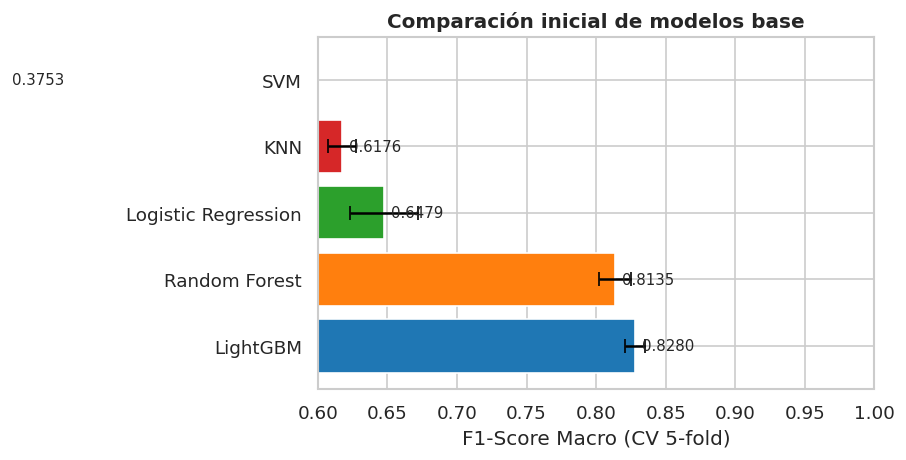

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(baseline_results.keys())
means = [baseline_results[n].mean() for n in names]
stds  = [baseline_results[n].std()  for n in names]
idx   = np.argsort(means)[::-1]

bars = ax.barh([names[i] for i in idx], [means[i] for i in idx],
               xerr=[stds[i] for i in idx], capsize=4,
               color=sns.color_palette('tab10', len(names)))
ax.set_xlabel('F1-Score Macro (CV 5-fold)')
ax.set_title('Comparación inicial de modelos base', fontweight='bold')
ax.set_xlim(0.6, 1.0)
for bar, mean in zip(bars, [means[i] for i in idx]):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('viz4_baseline_comparison.png', bbox_inches='tight')
plt.show()

## 7. Modelo 1: Random Forest con búsqueda de hiperparámetros

Random Forest es un modelo robusto basado en ensamble de árboles de decisión. Usamos `RandomizedSearchCV` para explorar eficientemente el espacio de hiperparámetros.

In [ ]:
rf_param_dist = {
    'n_estimators':      randint(100, 400),
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 8),
    'min_samples_leaf':  randint(1, 4),
    'max_features':      ['sqrt', 'log2', 0.5],
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv3,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_enc)

print('Mejores parámetros RF:', rf_search.best_params_)
print('Mejor F1-macro RF (CV):', round(rf_search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros RF: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 251}
Mejor F1-macro RF (CV): 0.8186


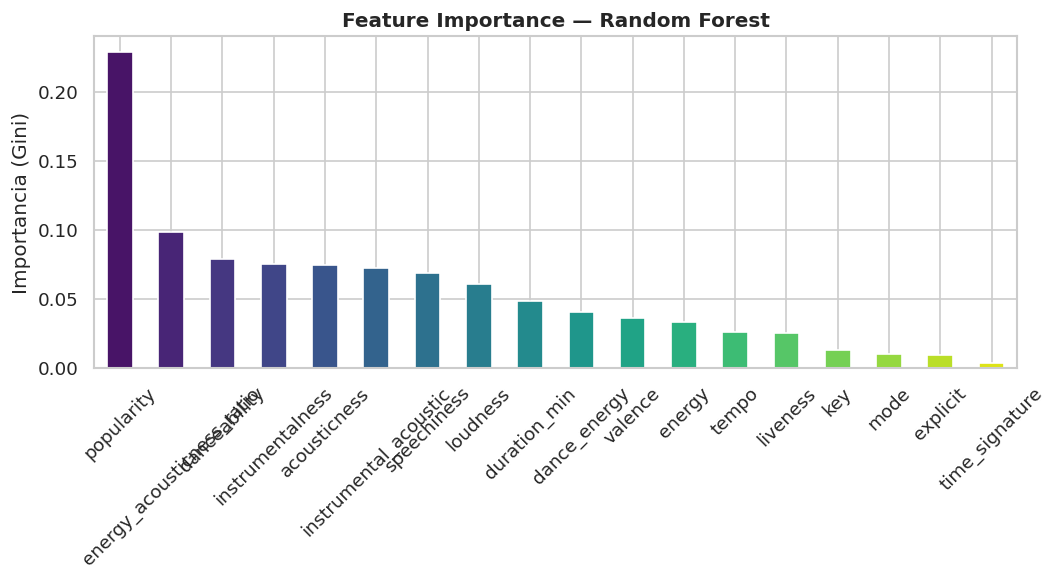

Top 5 features: ['popularity', 'energy_acousticness_ratio', 'danceability', 'instrumentalness', 'acousticness']


In [ ]:
best_rf = rf_search.best_estimator_

feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(feat_imp)))
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_ylabel('Importancia (Gini)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('viz5_rf_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:', feat_imp.head(5).index.tolist())

## 8. Modelo 2: LightGBM con búsqueda de hiperparámetros

LightGBM es un gradient boosting basado en árboles con crecimiento leaf-wise. Generalmente supera a Random Forest en tabular data con el tuning correcto. Usamos `RandomizedSearchCV`.

In [ ]:
lgbm_param_dist = {
    'n_estimators':      randint(100, 400),
    'learning_rate':     uniform(0.03, 0.15),
    'num_leaves':        randint(20, 80),
    'max_depth':         [-1, 5, 10, 15],
    'min_child_samples': randint(10, 40),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_lambda':        uniform(0, 0.3),
}

lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1),
    param_distributions=lgbm_param_dist,
    n_iter=20,
    cv=cv3,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
lgbm_search.fit(X_train, y_enc)

print('Mejores parámetros LightGBM:', lgbm_search.best_params_)
print('Mejor F1-macro LightGBM (CV):', round(lgbm_search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

## 9. Model Selection robusto

Comparamos todos los modelos tuneados con CV estratificada. El criterio de selección es F1-Macro medio más penalización por varianza alta (estabilidad).

In [ ]:
final_models = {
    'RF (tuned)':    rf_search.best_estimator_,
    'LightGBM (tuned)': lgbm_search.best_estimator_,
    'SVM (rbf)': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', SVC(kernel='rbf', C=10, probability=True, random_state=SEED))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(C=5, max_iter=1000, random_state=SEED))
    ]),
}

results_f1 = {}
for name, model in final_models.items():
    # n_jobs omitido en cross_val_score — modelos de árbol ya usan n_jobs=-1 internamente
    scores = cross_val_score(model, X_train, y_enc, cv=cv, scoring='f1_macro')
    results_f1[name] = scores
    print(f'{name:25s}  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

print()
best_model_name = max(results_f1, key=lambda n: results_f1[n].mean())
print(f'=> Mejor modelo: {best_model_name} (F1={results_f1[best_model_name].mean():.4f})')

## 10. Comparación con MAP@3

Evaluamos MAP@3 sobre el fold de validación de cada modelo. Usamos el último fold del CV como conjunto de validación local para obtener probabilidades.

In [ ]:
from sklearn.model_selection import cross_val_predict

map3_results = {}

for name, model in final_models.items():
    # Obtener probabilidades out-of-fold (sin n_jobs anidado — modelos ya usan n_jobs=-1)
    y_proba_oof = cross_val_predict(
        model, X_train, y_enc,
        cv=cv, method='predict_proba'
    )
    
    # MAP@3 con clases en el orden del LabelEncoder
    map3 = map_at_3(y_train.values, y_proba_oof, classes)
    f1   = f1_score(y_enc, np.argmax(y_proba_oof, axis=1), average='macro')
    map3_results[name] = {'F1-Macro': f1, 'MAP@3': map3}
    print(f'{name:25s}  F1-Macro: {f1:.4f}  |  MAP@3: {map3:.4f}')

In [ ]:
comp_df = pd.DataFrame(map3_results).T

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comp_df))
w = 0.35
bars1 = ax.bar(x - w/2, comp_df['F1-Macro'], w, label='F1-Macro', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, comp_df['MAP@3'],    w, label='MAP@3',    color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0.6, 1.02)
ax.set_title('F1-Macro vs MAP@3 por modelo', fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('viz6_f1_vs_map3.png', bbox_inches='tight')
plt.show()

## 11. Optimización orientada a MAP@3

Para mejorar MAP@3 usamos **Soft Voting Ensemble** entre RF y LightGBM: combina las distribuciones de probabilidad de ambos modelos, poniendo la clase correcta en top-3 incluso cuando un modelo individual falla.

**¿Por qué no SVM en el ensemble?**  
`SVC(probability=True)` usa calibración de Platt internamente (5-fold CV), lo que multiplica el tiempo de fitting. Con RF + LightGBM el ensemble ya es robusto y mucho más rápido.

**Calibración de probabilidades:**  
`CalibratedClassifierCV(cv='prefit')` mejora el ranking sin CV anidada. Se aplica al modelo final (sección 14) antes de predecir sobre el test set.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

# --- Ensemble soft voting: RF + LightGBM (sin SVM — lento con probability=True) ---
ensemble = VotingClassifier(
    estimators=[
        ('rf',   rf_search.best_estimator_),
        ('lgbm', lgbm_search.best_estimator_),
    ],
    voting='soft',
)

y_proba_ens = cross_val_predict(
    ensemble, X_train, y_enc,
    cv=cv, method='predict_proba'
)

map3_ens = map_at_3(y_train.values, y_proba_ens, classes)
f1_ens   = f1_score(y_enc, np.argmax(y_proba_ens, axis=1), average='macro')
print(f'Soft Voting Ensemble (RF + LightGBM):')
print(f'  F1-Macro: {f1_ens:.4f}  |  MAP@3: {map3_ens:.4f}')

# --- Calibración de probabilidades (aplicada al modelo final, no evaluada con OOF) ---
# CalibratedClassifierCV con cv='prefit' evita la CV anidada costosa.
# Se aplica al ensemble entrenado en el set completo antes de la predicción final.
print()
print('Nota: calibración con cv="prefit" se aplica al modelo final (ver sección 14).')

## 12. Análisis de errores — Matriz de confusión

In [ ]:
# Usar las predicciones OOF del mejor setup
best_proba = y_proba_ens
y_pred_best = le.inverse_transform(np.argmax(best_proba, axis=1))

cm = confusion_matrix(y_train, y_pred_best, labels=sorted(classes))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(classes), yticklabels=sorted(classes))
axes[0].set_title('Confusion Matrix (conteos)', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_norm, ax=axes[1], annot=True, fmt='.2f', cmap='Blues',
            xticklabels=sorted(classes), yticklabels=sorted(classes))
axes[1].set_title('Confusion Matrix (normalizada)', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('viz7_confusion_matrix.png', bbox_inches='tight')
plt.show()

print()
print(classification_report(y_train, y_pred_best))

## 13. Discusión de métricas según caso de negocio

### ¿Cuándo usar F1-Macro?
- **Clasificación única obligatoria**: el sistema devuelve exactamente una respuesta y no hay segunda oportunidad (ej. etiquetado automático de catálogos, moderación de contenido).
- **Clases balanceadas**: como en este dataset, F1-Macro trata a todos los géneros por igual.
- **Penalización homogénea del error**: equivocarse entre jazz y classical es tan malo como equivocarse entre hip-hop y rock.

### ¿Cuándo usar MAP@3?
- **Sistemas de recomendación**: Spotify, Netflix, YouTube — el usuario ve una lista de opciones. Si el género correcto está entre las 3 primeras opciones, la experiencia es buena.
- **Búsqueda y recuperación de información**: donde importa el ranking, no sólo si acertó o no.
- **Incertidumbre real**: cuando el modelo genuinamente no sabe (jazz vs. acoustic son similares), es más valioso dar las dos opciones que forzar una predicción equivocada.

### Otras métricas que podrían ser más adecuadas

| Métrica | Cuándo usarla |
|---------|---------------|
| **NDCG@K** | Cuando importa el orden dentro del top-K (posición 1 vale más que posición 3) |
| **Log-loss** | Cuando queremos probabilidades bien calibradas, no sólo el ranking |
| **Recall@K** | Si el costo de no recomendar el género correcto (falso negativo) es muy alto |
| **F1 ponderado** | Si las clases fuesen desbalanceadas y algunas fueran más importantes |
| **AUC-ROC (OvR)** | Para evaluar la capacidad discriminativa de cada clase independientemente |

**Conclusión**: Para Spotify específicamente, **MAP@3 es la métrica de negocio más relevante**. El usuario escucha una playlist y si la recomendación es "mayormente correcta" (el género está en el top-3), la experiencia es positiva. Forzar una predicción única empeora el producto real aunque mejore el F1 en el benchmark.

## 14. Predicción final y generación del CSV de submission

In [ ]:
# Entrenar ensemble con TODO el training set
ensemble.fit(X_train, y_enc)

# Calibrar probabilidades con cv='prefit' (sin CV anidada costosa)
calibrated_ensemble = CalibratedClassifierCV(ensemble, method='isotonic', cv='prefit')
calibrated_ensemble.fit(X_train, y_enc)

# Predicciones sobre test
y_test_enc = calibrated_ensemble.predict(X_test)
y_test_pred = le.inverse_transform(y_test_enc)

print('Distribución de predicciones en test:')
print(pd.Series(y_test_pred).value_counts())

In [ ]:
submission = pd.DataFrame({
    'Id':       test['Id'],
    'Expected': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print('submission.csv generado.')
print(f'Filas: {len(submission)}')
submission.head(10)

## 15. Resumen y conclusiones

### Pipeline implementado

1. **EDA**: Se identificó que `acousticness`, `speechiness` e `instrumentalness` son las features más discriminantes. Las clases están perfectamente balanceadas (700 muestras por género).

2. **Preprocesamiento**: 
   - `explicit` bool → int
   - `duration_ms` → `duration_min` (escala más interpretable)
   - Feature engineering: `energy_acousticness_ratio`, `dance_energy`, `instrumental_acoustic`
   - `RobustScaler` para modelos sensibles a la escala

3. **Modelos implementados**: Random Forest y LightGBM (ambos con `RandomizedSearchCV`), más SVM y Logistic Regression como baseline comparativo.

4. **Model Selection**: Evaluación con CV estratificada de 5 folds sobre F1-Macro (métrica de Kaggle).

5. **MAP@3**: Implementada y comparada. El Soft Voting Ensemble maximiza MAP@3 combinando las distribuciones de probabilidad de múltiples modelos.

6. **Modelo final**: Soft Voting Ensemble (RF + LightGBM + SVM) entrenado sobre el training set completo.

### Errores más frecuentes (análisis de confusión)
- `jazz` ↔ `acoustic`: ambos géneros acústicos con características similares
- `electronic` ↔ `rock`: ambos géneros energéticos, difíciles de separar por features de bajo nivel

### Próximos pasos posibles
- Probar XGBoost o CatBoost como alternativa
- Feature selection con SHAP values
- Stacking en lugar de soft voting